In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import random

from time import time

from scipy.special import comb, loggamma, lambertw
from scipy.stats import multinomial, expon

from silence_tensorflow import silence_tensorflow
silence_tensorflow()
import tensorflow as tf
import tensorflow_probability as tfp

config = tf.compat.v1.ConfigProto()
config.gpu_options.allow_growth = True
sess = tf.compat.v1.Session(config = config)

import os, shutil
from tqdm import tqdm
from pathlib import Path
import json
import subprocess

import thetaflow as thf
print("Thetaflow version: {}".format(thf.__version__))

import mps
import pwexp

E0000 00:00:1784665009.650273    9424 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1784665009.655221    9424 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1784665009.668220    9424 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1784665009.668249    9424 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1784665009.668251    9424 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1784665009.668254    9424 computation_placer.cc:177] computation placer already registered. Please check linka

Thetaflow version: 0.0.35


I0000 00:00:1784665012.382402    9424 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2253 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660, pci bus id: 0000:01:00.0, compute capability: 7.5
I0000 00:00:1784665012.420889    9424 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2253 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660, pci bus id: 0000:01:00.0, compute capability: 7.5
I0000 00:00:1784665012.456131    9424 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2253 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660, pci bus id: 0000:01:00.0, compute capability: 7.5
I0000 00:00:1784665012.457457    9424 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2253 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660, pci bus id: 0000:01:00.0, compute capability: 7.5


# Downloading OASIS data

### Subject demographics and AD Dementia assessment

In [2]:
# Merge information with patient-specific demographic data
oasis_demographics_df = pd.read_csv("OASIS Raw Data/OASIS3_demographics.csv")
# Filter only columns of interest for the analysis
oasis_demographics_df = oasis_demographics_df.loc[:, ["OASISID", "AgeatEntry", "AgeatDeath", "GENDER", "APOE"]]
oasis_demographics_df.head()
# final_metadata_MR = pd.merge(baseline_scans_group, oasis_demographics_df, left_on = "Subject", right_on = "OASISID", how = "inner")

,OASISID,AgeatEntry,AgeatDeath,GENDER,APOE
0,OAS30001,65.1945,NaN,2,23.0
1,OAS30002,67.2521,76.9397,1,34.0
2,OAS30003,58.8137,NaN,2,33.0
3,OAS30004,55.1342,NaN,2,23.0
4,OAS30005,48.0630,NaN,2,33.0


In [3]:
data_cdr = pd.read_csv("OASIS Raw Data/OASIS3_UDSb4_cdr.csv")
data_cdr.head(3)

,OASISID,OASIS_session_label,days_to_visit,age at visit,MMSE,memory,orient,judgment,commun,homehobb,...,dx1_code,dx2_code,dx3_code,dx4_code,dx5_code,dx1,dx2,dx3,dx4,dx5
0,OAS30001,OAS30001_UDSb4_d0000,0,65.19,28.0,0.0,0.0,0.0,0.0,0.0,...,1.0,NaN,NaN,NaN,NaN,Cognitively normal,.,.,.,.
1,OAS30001,OAS30001_UDSb4_d0339,339,66.12,28.0,0.0,0.0,0.0,0.0,0.0,...,1.0,NaN,NaN,NaN,NaN,Cognitively normal,.,.,.,.
2,OAS30001,OAS30001_UDSb4_d0722,722,67.17,30.0,0.0,0.0,0.0,0.0,0.0,...,1.0,NaN,NaN,NaN,NaN,Cognitively normal,.,.,.,.


In [4]:
def extract_survival_row(patient_data):
    event_rows = patient_data[ patient_data['CDRTOT'] > 0 ]
    if not event_rows.empty:
        # Patient hit CDR > 0: Return the FIRST time it happened (The Event)
        return event_rows.head(1)
    else:
        # Patient remained at CDR == 0: Return their LAST visit (The Censoring Time)
        return patient_data.tail(1)
        
survival_df = data_cdr.groupby("OASISID").apply(extract_survival_row, include_groups = False).reset_index(drop = False)
survival_df = survival_df.loc[:, ["OASISID", "days_to_visit", "age at visit", "CDRTOT", "dx1_code", "dx1"]]
# Include censoring indicator - Patients with a CDRTOT greater than 0 and whose dx1 code is not 150
# The dx1 code 150 stands for "0.5 in memory only", meaning the patients are not diagnosed with dementia,
# only showing minor signals of memory decay
survival_df["delta"] = ((survival_df["CDRTOT"] > 0) & (survival_df["dx1_code"] != 150)).astype(int)

# List of codes that are associated to Alzheimer's Disease
# Other types of dementia are not of our current interest for this study
AD_dx1_codes = [3, 5, 6, 9, 10, 11, 14, 44, 111, 112, 116, 117, 119, 120, 128, 133, 134, 135, 136, 137, 138, 139, 140, 141]

# Only select patients whose time is censored (CDR = 0 - delta = 0)
# or whose dementia event (CDR > 0) is directly associated to an Alzheimer's diagnostic
condition = (survival_df["delta"] == 0) | np.isin(survival_df["dx1_code"], AD_dx1_codes)
survival_df = survival_df.loc[ condition, : ]

# Remove subjects whose CDRTOT is missing
survival_df = survival_df.loc[ ~pd.isna(survival_df["CDRTOT"]), : ]

survival_df.head(3)

,OASISID,days_to_visit,age at visit,CDRTOT,dx1_code,dx1,delta
0,OAS30001,5184,79.40,0.0,1.0,Cognitively normal,0
1,OAS30002,2961,75.36,0.0,1.0,Cognitively normal,0
2,OAS30003,5651,74.30,0.0,1.0,Cognitively normal,0


Now that we extracted the final quantities of interest for each patient, we merge these to their specific demographic data.

In [5]:
patient_data = pd.merge(oasis_demographics_df, survival_df, left_on = "OASISID", right_on = "OASISID", how = "inner")
patient_data.head(3)

,OASISID,AgeatEntry,AgeatDeath,GENDER,APOE,days_to_visit,age at visit,CDRTOT,dx1_code,dx1,delta
0,OAS30001,65.1945,NaN,2,23.0,5184,79.40,0.0,1.0,Cognitively normal,0
1,OAS30002,67.2521,76.9397,1,34.0,2961,75.36,0.0,1.0,Cognitively normal,0
2,OAS30003,58.8137,NaN,2,33.0,5651,74.30,0.0,1.0,Cognitively normal,0


### Metadata recovery

In [6]:
oasis_MR_info = pd.read_csv("OASIS Raw Data/OASIS3_MR_json.csv")

oasis_MR_info["day"] = oasis_MR_info["label"].str.split("_d").str[-1].astype("int")
oasis_MR_info["day"]

subject_id = "OAS30001"
oasis_MR_subject_info = oasis_MR_info.loc[ oasis_MR_info["subject_id"] == subject_id, : ].sort_values(by = "day")
oasis_MR_subject_info.loc[ oasis_MR_subject_info["scan category"] == "T1w", : ].iloc[0, :]

subject_id                      OAS30001
label                  OAS30001_MR_d0129
acccession                CENTRAL_E09253
release version             2018 Release
scan category                        T1w
                             ...        
PhaseEncodingAxis                    NaN
AcquisitionDateTime                  NaN
PhaseEncodingLines                   NaN
AccelFactPE                          NaN
day                                  129
Name: 16682, Length: 69, dtype: object

In [7]:
# Load all the metadata information about the MR scans for every patient in the OASIS-3 database
oasis_MR_info = pd.read_csv("OASIS Raw Data/OASIS3_Freesurfer_output.csv")

# Split the scans IDs to recover the day when each patient took each MR scan
oasis_MR_info["day"] = oasis_MR_info["MR_session"].str.split("_d").str[-1].astype("int")

# Filter only T1W scans and sort them by day
oasis_MR_info_sorted = oasis_MR_info.sort_values(by = ["Subject", "day", "FS_FSDATA ID"])

# Select only the first observation for each subject. That corresponds to their first ever MR scan
baseline_scans_group = oasis_MR_info_sorted.groupby("Subject").first().reset_index()

final_metadata_MR = baseline_scans_group.loc[:, ["Subject", "day", "FS_FSDATA ID"]]
final_metadata_MR["MR ID"] = final_metadata_MR["FS_FSDATA ID"].str.split("_").apply(lambda x: f"{x[0]}_MR_{x[2]}")

display( final_metadata_MR.head() )

,Subject,day,FS_FSDATA ID,MR ID
0,OAS30001,129,OAS30001_Freesurfer53_d0129,OAS30001_MR_d0129
1,OAS30002,371,OAS30002_Freesurfer50_d0371,OAS30002_MR_d0371
2,OAS30003,558,OAS30003_Freesurfer53_d0558,OAS30003_MR_d0558
3,OAS30004,1101,OAS30004_Freesurfer53_d1101,OAS30004_MR_d1101
4,OAS30005,143,OAS30005_Freesurfer51_d0143,OAS30005_MR_d0143


### Brain MRI download

Once the earliest MR scans of interest have been defined, we can call the NITR database dynamically and download only the files of our interest. In this case, we are interested in gathering both the numerical variables from Freesurfer (tabular data for future studies) and the proper images, which we will be considering here to be from brainmask.mgz

In [8]:
import urllib3
import xnat
import logging
import pandas as pd
import os
import sys
import getpass
from contextlib import redirect_stdout, redirect_stderr

df_earliest_scans = final_metadata_MR.copy()

# Create data directory if it doesn't exist
os.makedirs("./OASIS Raw Data/brainmasks", exist_ok = True)

my_password = getpass.getpass("Enter NITRC password: ")

# Connect to the OASIS-3 server (NITRC-IR)
with open(os.devnull, "w") as fnull:
    # Connect to the NITRC server, dumping all unnecessary outputs to a void stdout
    with redirect_stdout(fnull), redirect_stderr(fnull):
        session = xnat.connect("https://www.nitrc.org/ir", user = "nhilarioh", password = my_password, verify = False)
        project = session.projects["OASIS3"]

with session:
    subject_id = "OAS30001"
    fs_id = "OAS30001_Freesurfer53_d0129"
    mr_id = fs_id.replace("Freesurfer53", "MR")
    try:
        print("Accessing MR Session: {}...".format(mr_id))
        mr_session = project.subjects[subject_id].experiments[mr_id]
        print("Accessing FreeSurfer Assessor: {}...".format(fs_id))
        fs_assessor = mr_session.assessors[fs_id]
        
        # Continue to find the path if next directory is "resources" or "out"
        if hasattr(fs_assessor, "resources") and fs_assessor.resources:
            res_collection = fs_assessor.resources
        elif hasattr(fs_assessor, "out") and fs_assessor.out:
            res_collection = fs_assessor.out
        # If resources do not exist, list the available attributes inside fs_assessor
        else:
            print("Could not locate the resources folder. Available attributes are:")
            print([a for a in dir(fs_assessor) if not a.startswith('_')])
            res_collection = {}
            
        # Search for brainmask.mgz inside res_collection
        target_file = None
        for resource_name, resource in res_collection.items():
            # Safely check if this resource actually has files
            if(hasattr(resource, "files")):
                for file_path, file_obj in resource.files.items():
                    # Dynamically search for a file whose name ends with "brainmask.mgz"
                    if file_path.endswith("brainmask.mgz"):
                        target_file = file_obj
                        print("Found target: {} in [{}]".format(file_path, resource_name))
                        break
            if target_file:
                break
                
        # Download the specific file
        if target_file:
            save_path = "./OASIS Raw Data/brainmasks/{}_brainmask.mgz".format(subject_id)
            print("Downloading to {}...".format(save_path))
            with open(os.devnull, 'w') as fnull:
                with redirect_stdout(fnull), redirect_stderr(fnull):
                    target_file.download(save_path)
            print("Download complete!")
        else:
            print("Could not find brainmask.mgz inside the assessor.")

    except KeyError as e:
        print(f"Warning: Could not find node {e} on the server.")

Enter NITRC password:  ········


Accessing MR Session: OAS30001_MR_d0129...
Accessing FreeSurfer Assessor: OAS30001_Freesurfer53_d0129...
Found target: OAS30001_MR_d0129/mri/brainmask.mgz in [123279552]


100% of   1.1 MiB |################################|   1.1 MiB/s Time:  0:00:0000


Download complete!


The above code successfully retrieves the brainmask.mgz file for a single patient OAS30001. Below, we implement the code to download all the MRI brain scan images for our study.

Before downloading everything from the OASIS-3 servers, first we select only those patients whose Alzheimer's diagnostic we have information of, from table patient_data.

In [8]:
print("Patients data dimension: {}".format(patient_data.shape))
print("MRI metadata dimension: {}".format(final_metadata_MR.shape))

patients_MRI_metadata = pd.merge(patient_data, final_metadata_MR, left_on = "OASISID", right_on = "Subject", how = "inner")
patients_MRI_metadata.columns = ["oasis_id", "age_at_entry", "age_at_death", "gender", "apoe",
                                 "days_to_visit", "age_at_visit", "cdr", "dx1_code", "dx1", "delta",
                                 "oasis_id2", "mri_days_to_visit", "freesurfer_id", "mr_id"]
patients_MRI_metadata = patients_MRI_metadata.loc[:, ["oasis_id", "delta", "age_at_entry", "age_at_death", "gender", "apoe",
                                                      "days_to_visit", "age_at_visit", "cdr", "dx1_code", "dx1",
                                                      "mri_days_to_visit", "freesurfer_id", "mr_id"]]

print("Patients MRI metadata dimension: {}".format(patients_MRI_metadata.shape))

patients_MRI_metadata.head(3)

Patients data dimension: (1092, 11)
MRI metadata dimension: (1316, 4)
Patients MRI metadata dimension: (1043, 14)


,oasis_id,delta,age_at_entry,age_at_death,gender,apoe,days_to_visit,age_at_visit,cdr,dx1_code,dx1,mri_days_to_visit,freesurfer_id,mr_id
0,OAS30001,0,65.1945,NaN,2,23.0,5184,79.40,0.0,1.0,Cognitively normal,129,OAS30001_Freesurfer53_d0129,OAS30001_MR_d0129
1,OAS30002,0,67.2521,76.9397,1,34.0,2961,75.36,0.0,1.0,Cognitively normal,371,OAS30002_Freesurfer50_d0371,OAS30002_MR_d0371
2,OAS30003,0,58.8137,NaN,2,33.0,5651,74.30,0.0,1.0,Cognitively normal,558,OAS30003_Freesurfer53_d0558,OAS30003_MR_d0558


Finally, we are able to take the time between the day each patient took the brain scan images and the first day they were diagnosed with AD.

In [9]:
patients_MRI_metadata.insert(1, "time_days", patients_MRI_metadata["days_to_visit"] - patients_MRI_metadata["mri_days_to_visit"])
# Filter out patients with negative times, which means they took their MRI after their last CDR assessment
patients_MRI_metadata = patients_MRI_metadata.loc[ patients_MRI_metadata["time_days"] > 0, : ]
print("Final dimension with times: {}".format(patients_MRI_metadata.shape))

patients_MRI_metadata.to_csv("OASIS Raw Data/patients_MRI_metadata.csv", index = False)

patients_MRI_metadata.head(3)

Final dimension with times: (737, 15)


,oasis_id,time_days,delta,age_at_entry,age_at_death,gender,apoe,days_to_visit,age_at_visit,cdr,dx1_code,dx1,mri_days_to_visit,freesurfer_id,mr_id
0,OAS30001,5055,0,65.1945,NaN,2,23.0,5184,79.40,0.0,1.0,Cognitively normal,129,OAS30001_Freesurfer53_d0129,OAS30001_MR_d0129
1,OAS30002,2590,0,67.2521,76.9397,1,34.0,2961,75.36,0.0,1.0,Cognitively normal,371,OAS30002_Freesurfer50_d0371,OAS30002_MR_d0371
2,OAS30003,5093,0,58.8137,NaN,2,33.0,5651,74.30,0.0,1.0,Cognitively normal,558,OAS30003_Freesurfer53_d0558,OAS30003_MR_d0558


In [17]:
import urllib3
import xnat
import logging
import pandas as pd
import os
import sys
import getpass
from contextlib import redirect_stdout, redirect_stderr
from tqdm import tqdm

df_earliest_scans = pd.read_csv("OASIS Raw Data/patients_MRI_metadata.csv")
# Create data directory if it doesn't exist
os.makedirs("./OASIS Raw Data/brainmasks", exist_ok = True)

my_password = getpass.getpass("Enter NITRC password: ")

# Connect to the OASIS-3 server (NITRC-IR)
with open(os.devnull, "w") as fnull:
    # Connect to the NITRC server, dumping all unnecessary outputs to a void stdout
    with redirect_stdout(fnull), redirect_stderr(fnull):
        session = xnat.connect("https://www.nitrc.org/ir", user = "nhilarioh", password = my_password, verify = False)
        project = session.projects["OASIS3"]

with session:
    for i in range( df_earliest_scans.shape[0] ):
        subject_id = df_earliest_scans.loc[i, "oasis_id"]
        fs_id = df_earliest_scans.loc[i,"freesurfer_id"]
        mr_id = df_earliest_scans.loc[i,"mr_id"]

        save_path = "./OASIS Raw Data/brainmasks/{}_brainmask.mgz".format(subject_id)
        # If file was already downloaded, skip its download
        if os.path.exists(save_path):
            print("Skipping {}. Already downloaded".format(subject_id))
            continue
        
        try:
            mr_session = project.subjects[subject_id].experiments[mr_id]
            fs_assessor = mr_session.assessors[fs_id]
            
            # Continue to find the path if next directory is "resources" or "out"
            if hasattr(fs_assessor, "resources") and fs_assessor.resources:
                res_collection = fs_assessor.resources
            elif hasattr(fs_assessor, "out") and fs_assessor.out:
                res_collection = fs_assessor.out
            # If resources do not exist, list the available attributes inside fs_assessor
            else:
                res_collection = {}
                
            # Search for brainmask.mgz inside res_collection
            target_file = None
            for resource_name, resource in res_collection.items():
                # Safely check if this resource actually has files
                if(hasattr(resource, "files")):
                    for file_path, file_obj in resource.files.items():
                        # Dynamically search for a file whose name ends with "brainmask.mgz"
                        if file_path.endswith("brainmask.mgz"):
                            target_file = file_obj
                            break
                if target_file:
                    break
                    
            # Download the specific file
            if target_file:
                try:
                    with open(os.devnull, 'w') as fnull:
                        with redirect_stdout(fnull), redirect_stderr(fnull):
                            target_file.download(save_path)
                except Exception as download_error:
                    # If it fails, delete the corrupted partial file and log it
                    if os.path.exists(save_path):
                        os.remove(save_path)
                    print("MD5/Network Error on {} MRI image. Skipping for now.".format(subject_id))
                    
        except KeyError as e:
            print("Error downloading {} MRI image. Skipping for now.".format(subject_id))

Enter NITRC password:  ········


Skipping OAS30001. Already downloaded
Skipping OAS30002. Already downloaded
Skipping OAS30003. Already downloaded
Skipping OAS30004. Already downloaded
Skipping OAS30005. Already downloaded
Skipping OAS30006. Already downloaded


100% of   1.2 MiB |################################|   1.6 MiB/s Time:  0:00:0000
100% of   1.3 MiB |################################|   2.0 MiB/s Time:  0:00:0000
100% of   1.1 MiB |################################|   2.0 MiB/s Time:  0:00:0000
100% of   1.1 MiB |################################|   1.6 MiB/s Time:  0:00:0000
100% of   1.1 MiB |################################|   1.6 MiB/s Time:  0:00:0000
100% of   1.3 MiB |################################|   1.9 MiB/s Time:  0:00:0000
100% of   1.2 MiB |################################|   2.8 MiB/s Time:  0:00:0000
100% of   1.3 MiB |################################|   2.7 MiB/s Time:  0:00:0000
100% of   1.3 MiB |################################|   2.4 MiB/s Time:  0:00:0000
100% of   1.2 MiB |################################|   2.2 MiB/s Time:  0:00:0000


MD5/Network Error on OAS30022 MRI image. Skipping for now.


100% of   1.1 MiB |################################|   2.5 MiB/s Time:  0:00:0000
100% of   1.4 MiB |################################|   1.8 MiB/s Time:  0:00:0000
100% of   1.3 MiB |################################|   2.4 MiB/s Time:  0:00:0000
100% of   1.0 MiB |################################|   2.7 MiB/s Time:  0:00:0000


...

100% of   1.2 MiB |################################|   4.7 MiB/s Time:  0:00:0000
100% of   1.2 MiB |################################|   3.0 MiB/s Time:  0:00:0000
100% of   1.3 MiB |################################|   3.1 MiB/s Time:  0:00:0000
100% of   1.4 MiB |################################|   3.1 MiB/s Time:  0:00:0000
100% of   1.2 MiB |################################|   2.7 MiB/s Time:  0:00:0000
100% of   1.2 MiB |################################|   3.2 MiB/s Time:  0:00:0000
100% of   1.2 MiB |################################|   2.5 MiB/s Time:  0:00:0000
100% of   1.3 MiB |################################|   3.2 MiB/s Time:  0:00:0000
100% of   1.0 MiB |################################|   2.2 MiB/s Time:  0:00:0000


MD5/Network Error on OAS31142 MRI image. Skipping for now.


100% of   1.1 MiB |################################|   3.0 MiB/s Time:  0:00:0000
100% of   1.1 MiB |################################|   2.9 MiB/s Time:  0:00:0000
100% of   1.2 MiB |################################|   2.8 MiB/s Time:  0:00:0000
100% of   1.4 MiB |################################|   2.5 MiB/s Time:  0:00:0000
100% of   1.0 MiB |################################|   2.9 MiB/s Time:  0:00:0000
100% of   1.1 MiB |################################|   3.0 MiB/s Time:  0:00:0000
100% of   1.0 MiB |################################|   2.5 MiB/s Time:  0:00:0000
100% of   1.2 MiB |################################|   2.7 MiB/s Time:  0:00:0000
100% of   1.2 MiB |################################|   4.7 MiB/s Time:  0:00:0000
100% of   1.2 MiB |################################|   2.8 MiB/s Time:  0:00:0000
100% of   1.2 MiB |################################|   2.1 MiB/s Time:  0:00:0000
100% of   1.3 MiB |################################|   1.8 MiB/s Time:  0:00:0000
100% of   1.2 Mi

MD5/Network Error on OAS31167 MRI image. Skipping for now.


100% of   1.3 MiB |################################|   3.4 MiB/s Time:  0:00:0000
100% of   1.3 MiB |################################|   4.2 MiB/s Time:  0:00:0000
100% of   1.3 MiB |################################|   4.3 MiB/s Time:  0:00:0000
100% of   1.3 MiB |################################|   3.3 MiB/s Time:  0:00:0000
100% of   1.2 MiB |################################|   2.1 MiB/s Time:  0:00:0000
100% of   1.4 MiB |################################|   2.0 MiB/s Time:  0:00:0000
100% of   1.3 MiB |################################|   1.3 MiB/s Time:  0:00:0000
100% of   1.1 MiB |################################|   1.8 MiB/s Time:  0:00:0000
100% of   1.2 MiB |################################|   2.1 MiB/s Time:  0:00:0000
100% of   1.4 MiB |################################|   2.3 MiB/s Time:  0:00:0000
100% of   1.2 MiB |################################|   2.8 MiB/s Time:  0:00:0000
100% of   1.3 MiB |################################|   2.9 MiB/s Time:  0:00:0000
100% of   1.2 Mi

By running the same code a second time, we see that the remaining files that resulted in MD5/Network Errors may be directly linked to outdated MD5 file checks from the server, instead of a corruption on the download process itself. For that reason, we slightly alter the code to keep the downloaded files even if they result in an error.

In [19]:
import urllib3
import xnat
import logging
import pandas as pd
import os
import sys
import getpass
from contextlib import redirect_stdout, redirect_stderr
from tqdm import tqdm

df_earliest_scans = pd.read_csv("OASIS Raw Data/patients_MRI_metadata.csv")
# Create data directory if it doesn't exist
os.makedirs("./OASIS Raw Data/brainmasks", exist_ok = True)

my_password = getpass.getpass("Enter NITRC password: ")

# Connect to the OASIS-3 server (NITRC-IR)
with open(os.devnull, "w") as fnull:
    # Connect to the NITRC server, dumping all unnecessary outputs to a void stdout
    with redirect_stdout(fnull), redirect_stderr(fnull):
        session = xnat.connect("https://www.nitrc.org/ir", user = "nhilarioh", password = my_password, verify = False)
        project = session.projects["OASIS3"]

with session:
    for i in range( df_earliest_scans.shape[0] ):
        subject_id = df_earliest_scans.loc[i, "oasis_id"]
        fs_id = df_earliest_scans.loc[i,"freesurfer_id"]
        mr_id = df_earliest_scans.loc[i,"mr_id"]

        save_path = "./OASIS Raw Data/brainmasks/{}_brainmask.mgz".format(subject_id)
        # If file was already downloaded, skip its download
        if os.path.exists(save_path):
            # print("Skipping {}. Already downloaded".format(subject_id))
            continue

        print("Retrying download for {}".format(subject_id))
        
        try:
            mr_session = project.subjects[subject_id].experiments[mr_id]
            fs_assessor = mr_session.assessors[fs_id]
            
            # Continue to find the path if next directory is "resources" or "out"
            if hasattr(fs_assessor, "resources") and fs_assessor.resources:
                res_collection = fs_assessor.resources
            elif hasattr(fs_assessor, "out") and fs_assessor.out:
                res_collection = fs_assessor.out
            # If resources do not exist, list the available attributes inside fs_assessor
            else:
                res_collection = {}
                
            # Search for brainmask.mgz inside res_collection
            target_file = None
            for resource_name, resource in res_collection.items():
                # Safely check if this resource actually has files
                if(hasattr(resource, "files")):
                    for file_path, file_obj in resource.files.items():
                        # Dynamically search for a file whose name ends with "brainmask.mgz"
                        if file_path.endswith("brainmask.mgz"):
                            target_file = file_obj
                            break
                if target_file:
                    break
                    
            # Download the specific file
            if target_file:
                try:
                    with open(os.devnull, 'w') as fnull:
                        with redirect_stdout(fnull), redirect_stderr(fnull):
                            target_file.download(save_path)
                except xnat.exceptions.XNATValueError:
                    # The file downloaded, but the server's MD5 record is outdated.
                    print("Server MD5 outdated for {}. File kept.".format(subject_id))
                    
        except KeyError as e:
            print("Error downloading {} MRI image. Skipping for now.".format(subject_id))

Enter NITRC password:  ········


Retrying download for OAS30022


100% of   1.2 MiB |################################|   2.1 MiB/s Time:  0:00:0000


Server MD5 outdated for OAS30022. File kept.
Retrying download for OAS30032


100% of   1.0 MiB |################################|   2.8 MiB/s Time:  0:00:0000


...

Server MD5 outdated for OAS31122. File kept.
Retrying download for OAS31142


100% of   1.0 MiB |################################|   1.3 MiB/s Time:  0:00:0000


Server MD5 outdated for OAS31142. File kept.
Retrying download for OAS31167


100% of   1.2 MiB |################################|   1.2 MiB/s Time:  0:00:0000


Server MD5 outdated for OAS31167. File kept.


### Freesurfer extra data

In [56]:
import urllib3
import xnat
import logging
import pandas as pd
import os
import getpass
from tqdm import tqdm

df_earliest_scans = pd.read_csv("OASIS Raw Data/patients_MRI_metadata.csv")
# Create a new directory for the Freesurfer XML files
os.makedirs("./OASIS Raw Data/freesurfer_xmls", exist_ok = True)

my_password = getpass.getpass("Enter NITRC password: ")

# Silence the warnings
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
logging.getLogger("xnat").setLevel(logging.ERROR)

# Connect to the OASIS-3 server (NITRC-IR)
with open(os.devnull, "w") as fnull:
    # Connect to the NITRC server, dumping all unnecessary outputs to a void stdout
    with redirect_stdout(fnull), redirect_stderr(fnull):
        session = xnat.connect("https://www.nitrc.org/ir", user = "nhilarioh", password = my_password, verify = False)
        project = session.projects["OASIS3"]

with session:
    project = session.projects["OASIS3"]
    
    for i in tqdm(range(df_earliest_scans.shape[0])):
        subject_id = df_earliest_scans.loc[i, "oasis_id"]
        fs_id = df_earliest_scans.loc[i, "freesurfer_id"]
        mr_id = df_earliest_scans.loc[i, "mr_id"]
        
        save_path = "./OASIS Raw Data/freesurfer_xmls/{}_freesurfer.xml".format(subject_id)
        
        # Skip if already downloaded
        if os.path.exists(save_path):
            continue
            
        try:
            mr_session = project.subjects[subject_id].experiments[mr_id]
            fs_assessor = mr_session.assessors[fs_id]

            xml_uri = f"{fs_assessor.uri}?format=xml"
            xml_response = session.get(xml_uri)
            
            # Save the raw text response directly as an XML file
            with open(save_path, "w", encoding = "utf-8") as f:
                f.write(xml_response.text)
                
        except KeyError:
            tqdm.write("Error locating {} on the server. Skipping.".format(subject_id))
        except Exception as e:
            tqdm.write("Network error on {}: {}".format(subject_id, e))

Enter NITRC password:  ········


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 737/737 [17:26<00:00,  1.42s/it]


Finally, now we can merge the extra variables from the Freesurfer software into the same data tables for patients, having a single, consisent summary of the brain MRI in tabular form, together with their observed times. For this specific work, we are interested mainly on the images, so this table will not be used directly. However, it is a very usefull dataset for future research.

In [3]:
import xml.etree.ElementTree as ET

xml_path = "OASIS Raw Data/freesurfer_xmls/OAS30001_freesurfer.xml"
tree = ET.parse(xml_path)
root = tree.getroot()

# XNAT/FreeSurfer uses the 'fs' namespace for its volumetric measures
namespaces = {"fs": "http://nrg.wustl.edu/fs"}
data = {}

# Extract the Subject/Session ID from the root attributes
session_label = root.attrib.get("label")
data["Session_ID"] = session_label

if session_label:
    data["Subject_ID"] = session_label.split("_")[0]

num_quantities = ["ICV", "lhCortexVol", "rhCortexVol", "CortexVol",
                  "SubCortGrayVol", "TotalGrayVol", "SupraTentorialVol", "lhCorticalWhiteMatterVol",
                  "rhCorticalWhiteMatterVol", "CorticalWhiteMatterVol"]

for col in num_quantities:
    node = root.find(".//fs:{}".format(col), namespaces)
    data[col] = float(node.text) if node is not None else None
print(data)

{'Session_ID': 'OAS30001_Freesurfer53_d0129', 'Subject_ID': 'OAS30001', 'ICV': 1136503.981158, 'lhCortexVol': 191917.394056, 'rhCortexVol': 187528.786036, 'CortexVol': 379446.180091, 'SubCortGrayVol': 50687.0, 'TotalGrayVol': 517683.180091, 'SupraTentorialVol': 810585.11357, 'lhCorticalWhiteMatterVol': 184600.48806, 'rhCorticalWhiteMatterVol': 182662.445419, 'CorticalWhiteMatterVol': 367262.933479}


In [2]:
def load_xml_patient(subject_id):
    xml_path = "OASIS Raw Data/freesurfer_xmls/{}_freesurfer.xml".format(subject_id)
    tree = ET.parse(xml_path)
    root = tree.getroot()
    
    # XNAT/FreeSurfer uses the 'fs' namespace for its volumetric measures
    namespaces = {"fs": "http://nrg.wustl.edu/fs"}
    data = {}
    
    # Extract the Subject/Session ID from the root attributes
    session_label = root.attrib.get("label")
    data["Session_ID"] = session_label
    
    if session_label:
        data["Subject_ID"] = session_label.split("_")[0]
    
    num_quantities = ["ICV", "lhCortexVol", "rhCortexVol", "CortexVol",
                      "SubCortGrayVol", "TotalGrayVol", "SupraTentorialVol", "lhCorticalWhiteMatterVol",
                      "rhCorticalWhiteMatterVol", "CorticalWhiteMatterVol"]
    
    for col in num_quantities:
        node = root.find(".//fs:{}".format(col), namespaces)
        data[col] = float(node.text) if node is not None else None
    return data

In [4]:
import xml.etree.ElementTree as ET

import re
import pandas as pd

def to_snake_case(name):
    """
        Converts different text types into a standard_text_structure.
    """
    
    # Insert an underscore between a lowercase letter/number and an uppercase letter
    s1 = re.sub(r'([a-z0-9])([A-Z])', r'\1_\2', name)
    
    # Replace all hyphens with underscores
    s2 = s1.replace('-', '_')
    
    # Convert the entire string to lowercase
    s3 = s2.lower()
    
    # 4. Clean up any accidental double underscores just in case
    clean_name = re.sub(r'_+', '_', s3)
    
    return clean_name

def load_xml_patient(subject_id):
    xml_path = "OASIS Raw Data/freesurfer_xmls/{}_freesurfer.xml".format(subject_id)
    tree = ET.parse(xml_path)
    root = tree.getroot()
    
    # XNAT/FreeSurfer uses the 'fs' namespace for its volumetric measures
    namespaces = {"fs": "http://nrg.wustl.edu/fs"}
    data = {}
    
    # Extract the Subject/Session ID from the root attributes
    session_label = root.attrib.get("label")
    data["Session_ID"] = session_label
    
    if session_label:
        data["Subject_ID"] = session_label.split("_")[0]
    
    # Global Volumetric Quantities
    num_quantities = [
        "ICV", "lhCortexVol", "rhCortexVol", "CortexVol",
        "SubCortGrayVol", "TotalGrayVol", "SupraTentorialVol", 
        "lhCorticalWhiteMatterVol", "rhCorticalWhiteMatterVol", 
        "CorticalWhiteMatterVol"
    ]
    
    for col in num_quantities:
        node = root.find(".//fs:{}".format(col), namespaces)
        data[col] = float(node.text) if node is not None else None

    # Subcortical Regions (Volumes)
    # Search for structures like the Hippocampus, Amygdala, and Ventricles
    for region in root.findall(".//fs:volumetric/fs:regions/fs:region", namespaces):
        region_name = region.attrib.get("name")
        vol_node = region.find("fs:Volume", namespaces)
        
        if region_name and vol_node is not None:
            # Prefix with 'Vol_' to keep DataFrame columns organized
            data["Vol_{}".format(region_name)] = float(vol_node.text)

    #  Cortical Surface Regions (Thickness & Volume)
    # Iterates through both the left and right hemispheres
    for hemi in root.findall(".//fs:surface/fs:hemisphere", namespaces):
        hemi_name = hemi.attrib.get("name")
        # Create a prefix like 'lh' or 'rh'
        prefix = "lh" if hemi_name == "left" else "rh"
        
        for region in hemi.findall(".//fs:regions/fs:region", namespaces):
            region_name = region.attrib.get("name")
            
            # Extract both Thickness and Gray Matter Volume
            thick_node = region.find("fs:ThickAvg", namespaces)
            grayvol_node = region.find("fs:GrayVol", namespaces)
            
            if region_name:
                if thick_node is not None:
                    data["Thick_{}_{}".format(prefix, region_name)] = float(thick_node.text)
                if grayvol_node is not None:
                    data["Vol_{}_{}".format(prefix, region_name)] = float(grayvol_node.text)
    
    return data

In [5]:
patients_MRI_metadata = pd.read_csv("OASIS Raw Data/patients_MRI_metadata.csv")

freesurfer_data_list = []
for i in tqdm(range(patients_MRI_metadata.shape[0])):
    patient_xml_data = load_xml_patient( patients_MRI_metadata.loc[i, "oasis_id"] )
    if(patient_xml_data is not None):
        freesurfer_data_list.append( patient_xml_data )

freesurfer_data = pd.DataFrame(freesurfer_data_list)
freesurfer_data.columns = [to_snake_case(col) for col in freesurfer_data.columns]
freesurfer_data = freesurfer_data.iloc[:,1:]
freesurfer_data.head(3)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 737/737 [00:02<00:00, 347.72it/s]


,subject_id,icv,lh_cortex_vol,rh_cortex_vol,cortex_vol,sub_cort_gray_vol,total_gray_vol,supra_tentorial_vol,lh_cortical_white_matter_vol,rh_cortical_white_matter_vol,...,vol_wm_rh_superiorfrontal,vol_wm_rh_superiorparietal,vol_wm_rh_superiortemporal,vol_wm_rh_supramarginal,vol_wm_rh_frontalpole,vol_wm_rh_temporalpole,vol_wm_rh_transversetemporal,vol_wm_rh_insula,vol_left_unsegmented_white_matter,vol_right_unsegmented_white_matter
0,OAS30001,1.136504e+06,191917.394056,187528.786036,379446.180091,50687.0,517683.180091,810585.113570,184600.488060,182662.445419,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,OAS30002,1.704842e+06,236741.532768,233487.687424,470229.220192,195096.0,665325.220192,NaN,270296.078125,280666.171875,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,OAS30003,1.449811e+06,206641.011307,214696.395609,421337.406916,59540.0,569622.406916,953803.462384,226794.049522,229032.005946,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
patient_full_data = pd.read_csv("OASIS Raw Data/patients_MRI_metadata.csv")
patient_full_data = pd.merge(patient_full_data, freesurfer_data, left_on = "oasis_id", right_on = "subject_id", how = "left")
patient_full_data.to_csv("OASIS Data/patients_full_data.csv", index = False)
patient_full_data.head()

,oasis_id,time_days,delta,age_at_entry,age_at_death,gender,apoe,days_to_visit,age_at_visit,cdr,...,vol_wm_rh_superiorfrontal,vol_wm_rh_superiorparietal,vol_wm_rh_superiortemporal,vol_wm_rh_supramarginal,vol_wm_rh_frontalpole,vol_wm_rh_temporalpole,vol_wm_rh_transversetemporal,vol_wm_rh_insula,vol_left_unsegmented_white_matter,vol_right_unsegmented_white_matter
0,OAS30001,5055,0,65.1945,NaN,2,23.0,5184,79.40,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,OAS30002,2590,0,67.2521,76.9397,1,34.0,2961,75.36,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,OAS30003,5093,0,58.8137,NaN,2,33.0,5651,74.30,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,OAS30004,4411,0,55.1342,NaN,2,23.0,5512,70.24,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,OAS30005,4274,0,48.0630,NaN,2,33.0,4417,60.16,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


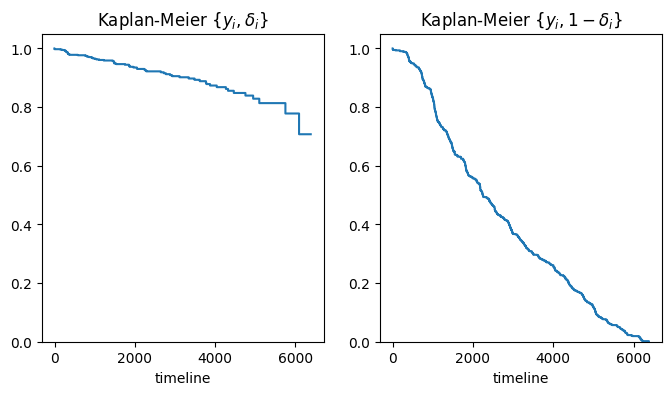

In [7]:
import lifelines
from lifelines.utils import concordance_index
from lifelines.statistics import logrank_test

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (8,4))

km = lifelines.KaplanMeierFitter()
km.fit(patient_full_data["time_days"], patient_full_data["delta"])
km.plot(ax = ax[0], ci_show = False, show_censors = False, legend = False)
ax[0].set_ylim(0,1.05)
ax[0].set_title(r"Kaplan-Meier $\{y_i, \delta_i\}$")

km = lifelines.KaplanMeierFitter()
km.fit(patient_full_data["time_days"], 1-patient_full_data["delta"])
km.plot(ax = ax[1], ci_show = False, show_censors = False, legend = False)
ax[1].set_ylim(0,1.05)
ax[1].set_title(r"Kaplan-Meier $\{y_i, 1-\delta_i\}$")

plt.show()

As the Kaplan-Meier suggests, there is a very high rate of censoring in this dataset. By inverting the event indicator and building the Kaplan-Meier plot we also notice that the right censoring surely seems to be random and that we possibly obtained sufficient follow-up from the actual distribution of susceptibles in the base distribution.

# Pre-processing

(256, 256, 256)


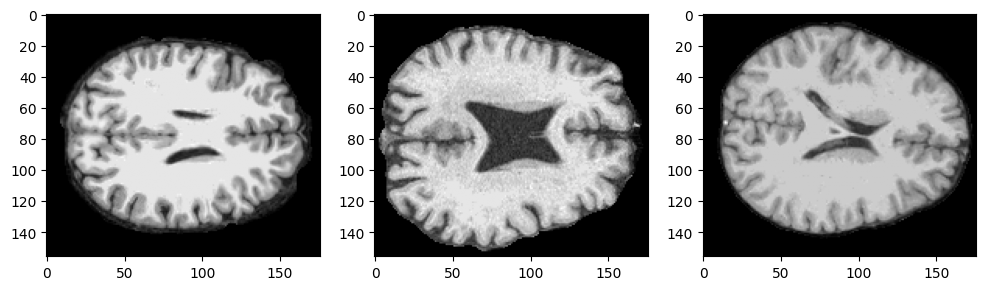

In [8]:
import nibabel as nib

fig, ax = plt.subplots(nrows = 1, ncols = 3, figsize = (12,4))

img1 = nib.load("OASIS Raw Data/brainmasks/OAS30001_brainmask.mgz")
img2 = nib.load("OASIS Raw Data/brainmasks/OAS30002_brainmask.mgz")
img3 = nib.load("OASIS Raw Data/brainmasks/OAS30005_brainmask.mgz")

brain1 = img1.get_fdata()
brain2 = img2.get_fdata()
brain3 = img3.get_fdata()
print(brain1.shape)

middle_cut = 106
height_cut_lower = 50
height_cut_upper = 50
width_cut_lower = 30
width_cut_upper = 50

middle_slice1 = brain1[height_cut_lower:-height_cut_upper, middle_cut, width_cut_lower:-width_cut_upper]
middle_slice2 = brain2[height_cut_lower:-height_cut_upper, middle_cut, width_cut_lower:-width_cut_upper]
middle_slice3 = brain3[height_cut_lower:-height_cut_upper, middle_cut, width_cut_lower:-width_cut_upper]

ax[0].imshow( middle_slice1, cmap = "gray" )
ax[1].imshow( middle_slice2, cmap = "gray" )
ax[2].imshow( middle_slice3, cmap = "gray" )

plt.show()

In [9]:
from scipy.ndimage import center_of_mass

def plot_centralized_brain(brain, height_cut_lower, height_cut_upper, width_cut_lower, width_cut_upper, middle_cut_diff, ax = None):
    if(ax is None):
        fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (6, 4))
    
    binary_brain = (brain > 0)
    center_coords = center_of_mass(binary_brain)
    center_coords_int = np.round(center_coords).astype("int")
    
    middle_cut = center_coords_int[1] - middle_cut_diff
    height_lower = center_coords_int[0] - height_cut_lower
    height_upper = center_coords_int[0] + height_cut_upper
    width_lower = center_coords_int[0] - width_cut_lower
    width_upper = center_coords_int[0] + width_cut_upper

    ax.imshow( brain[height_lower:height_upper, middle_cut, width_lower:width_upper], cmap = "gray" )
    ax.set_title("Diff: {}".format(middle_cut_diff))

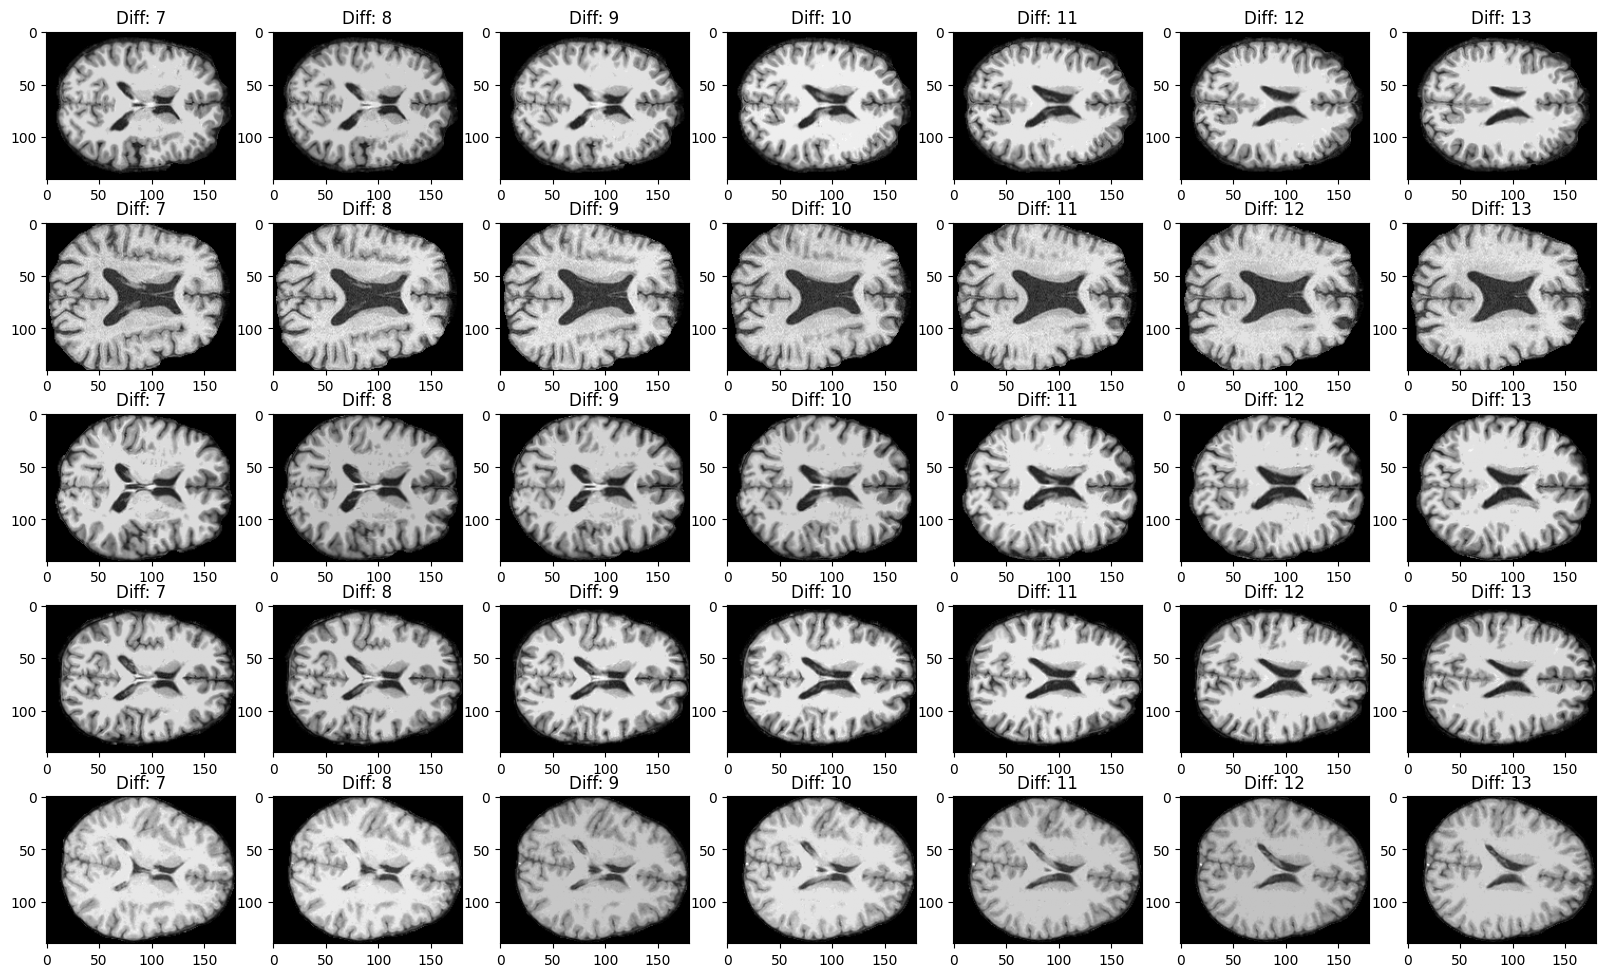

In [10]:
fig, ax = plt.subplots(nrows = 5, ncols = 7, figsize = (20, 12))

img1 = nib.load("OASIS Raw Data/brainmasks/OAS30001_brainmask.mgz")
img2 = nib.load("OASIS Raw Data/brainmasks/OAS30002_brainmask.mgz")
img3 = nib.load("OASIS Raw Data/brainmasks/OAS30003_brainmask.mgz")
img4 = nib.load("OASIS Raw Data/brainmasks/OAS30004_brainmask.mgz")
img5 = nib.load("OASIS Raw Data/brainmasks/OAS30005_brainmask.mgz")
# img1 = nib.load("OASIS Raw Data/brainmasks/OAS30006_brainmask.mgz")
# img2 = nib.load("OASIS Raw Data/brainmasks/OAS30008_brainmask.mgz")
# img3 = nib.load("OASIS Raw Data/brainmasks/OAS30009_brainmask.mgz")
# img4 = nib.load("OASIS Raw Data/brainmasks/OAS30010_brainmask.mgz")
# img5 = nib.load("OASIS Raw Data/brainmasks/OAS30011_brainmask.mgz")

brain1 = img1.get_fdata()
brain2 = img2.get_fdata()
brain3 = img3.get_fdata()
brain4 = img4.get_fdata()
brain5 = img5.get_fdata()

height_cut_lower = 70
height_cut_upper = 70
width_cut_lower = 100
width_cut_upper = 80

plot_centralized_brain(brain1, height_cut_lower, height_cut_upper, width_cut_lower, width_cut_upper, 7, ax = ax[0,0])
plot_centralized_brain(brain1, height_cut_lower, height_cut_upper, width_cut_lower, width_cut_upper, 8, ax = ax[0,1])
plot_centralized_brain(brain1, height_cut_lower, height_cut_upper, width_cut_lower, width_cut_upper, 9, ax = ax[0,2])
plot_centralized_brain(brain1, height_cut_lower, height_cut_upper, width_cut_lower, width_cut_upper, 10, ax = ax[0,3])
plot_centralized_brain(brain1, height_cut_lower, height_cut_upper, width_cut_lower, width_cut_upper, 11, ax = ax[0,4])
plot_centralized_brain(brain1, height_cut_lower, height_cut_upper, width_cut_lower, width_cut_upper, 12, ax = ax[0,5])
plot_centralized_brain(brain1, height_cut_lower, height_cut_upper, width_cut_lower, width_cut_upper, 13, ax = ax[0,6])

plot_centralized_brain(brain2, height_cut_lower, height_cut_upper, width_cut_lower, width_cut_upper, 7, ax = ax[1,0])
plot_centralized_brain(brain2, height_cut_lower, height_cut_upper, width_cut_lower, width_cut_upper, 8, ax = ax[1,1])
plot_centralized_brain(brain2, height_cut_lower, height_cut_upper, width_cut_lower, width_cut_upper, 9, ax = ax[1,2])
plot_centralized_brain(brain2, height_cut_lower, height_cut_upper, width_cut_lower, width_cut_upper, 10, ax = ax[1,3])
plot_centralized_brain(brain2, height_cut_lower, height_cut_upper, width_cut_lower, width_cut_upper, 11, ax = ax[1,4])
plot_centralized_brain(brain2, height_cut_lower, height_cut_upper, width_cut_lower, width_cut_upper, 12, ax = ax[1,5])
plot_centralized_brain(brain2, height_cut_lower, height_cut_upper, width_cut_lower, width_cut_upper, 13, ax = ax[1,6])

plot_centralized_brain(brain3, height_cut_lower, height_cut_upper, width_cut_lower, width_cut_upper, 7, ax = ax[2,0])
plot_centralized_brain(brain3, height_cut_lower, height_cut_upper, width_cut_lower, width_cut_upper, 8, ax = ax[2,1])
plot_centralized_brain(brain3, height_cut_lower, height_cut_upper, width_cut_lower, width_cut_upper, 9, ax = ax[2,2])
plot_centralized_brain(brain3, height_cut_lower, height_cut_upper, width_cut_lower, width_cut_upper, 10, ax = ax[2,3])
plot_centralized_brain(brain3, height_cut_lower, height_cut_upper, width_cut_lower, width_cut_upper, 11, ax = ax[2,4])
plot_centralized_brain(brain3, height_cut_lower, height_cut_upper, width_cut_lower, width_cut_upper, 12, ax = ax[2,5])
plot_centralized_brain(brain3, height_cut_lower, height_cut_upper, width_cut_lower, width_cut_upper, 13, ax = ax[2,6])

plot_centralized_brain(brain4, height_cut_lower, height_cut_upper, width_cut_lower, width_cut_upper, 7, ax = ax[3,0])
plot_centralized_brain(brain4, height_cut_lower, height_cut_upper, width_cut_lower, width_cut_upper, 8, ax = ax[3,1])
plot_centralized_brain(brain4, height_cut_lower, height_cut_upper, width_cut_lower, width_cut_upper, 9, ax = ax[3,2])
plot_centralized_brain(brain4, height_cut_lower, height_cut_upper, width_cut_lower, width_cut_upper, 10, ax = ax[3,3])
plot_centralized_brain(brain4, height_cut_lower, height_cut_upper, width_cut_lower, width_cut_upper, 11, ax = ax[3,4])
plot_centralized_brain(brain4, height_cut_lower, height_cut_upper, width_cut_lower, width_cut_upper, 12, ax = ax[3,5])
plot_centralized_brain(brain4, height_cut_lower, height_cut_upper, width_cut_lower, width_cut_upper, 13, ax = ax[3,6])

plot_centralized_brain(brain5, height_cut_lower, height_cut_upper, width_cut_lower, width_cut_upper, 7, ax = ax[4,0])
plot_centralized_brain(brain5, height_cut_lower, height_cut_upper, width_cut_lower, width_cut_upper, 8, ax = ax[4,1])
plot_centralized_brain(brain5, height_cut_lower, height_cut_upper, width_cut_lower, width_cut_upper, 9, ax = ax[4,2])
plot_centralized_brain(brain5, height_cut_lower, height_cut_upper, width_cut_lower, width_cut_upper, 10, ax = ax[4,3])
plot_centralized_brain(brain5, height_cut_lower, height_cut_upper, width_cut_lower, width_cut_upper, 11, ax = ax[4,4])
plot_centralized_brain(brain5, height_cut_lower, height_cut_upper, width_cut_lower, width_cut_upper, 12, ax = ax[4,5])
plot_centralized_brain(brain5, height_cut_lower, height_cut_upper, width_cut_lower, width_cut_upper, 13, ax = ax[4,6])

From the images above, it seems that the optimal point to cut the brain seems to be considering an offset of 11 pixels from the brain's center of mass. Indeed, the column corresponding to 11 appears to be the one that better pronunciate the brain ventricles along the entire brain cross-sectional cut. Therefore, we consider the final images to be extracted as below.

In [118]:
# def centralize_brain2(brain, height_size, width_size, slice_percentage = 0.5, ax = None):
#     """
#         Crops a 2D slice from a 3D brain array based on a percentage of the anatomical bounding box.
#     """
    
#     binary_brain = (brain > 0)
    
#     # Find the absolute boundaries (bounding box) of the brain
#     coords = np.array(np.where(binary_brain))
    
#     # Get the min and max coordinates for all 3 axes
#     min_coords = coords.min(axis=1)
#     max_coords = coords.max(axis=1)
    
#     # Calculate the physical size of the brain along the slicing axis (axis 1)
#     slice_axis_min = min_coords[1]
#     slice_axis_length = max_coords[1] - min_coords[1]
    
#     # Dynamically calculate the middle cut based on the percentage
#     # A percentage of 0.5 targets the anatomical midline
#     middle_cut = int(slice_axis_min + (slice_axis_length * slice_percentage))
        
#     # Use Center of Mass to center the crop in the other two dimensions
#     center_coords_int = np.round(center_of_mass(binary_brain)).astype(int)
    
#     # Calculate half-sizes for the bounding crop
#     h_half = height_size // 2
#     w_half = width_size // 2
    
#     # Apply the crop
#     height_lower = center_coords_int[0] - h_half
#     height_upper = center_coords_int[0] + h_half
#     width_lower = center_coords_int[2] - w_half
#     width_upper = center_coords_int[2] + w_half

#     return brain[height_lower:height_upper, middle_cut, (width_lower+10):width_upper]

In [136]:
def centralize_brain(brain, height_cut_lower, height_cut_upper, width_cut_lower, width_cut_upper, middle_cut_diff, ax = None):    
    binary_brain = (brain > 0)
    center_coords = center_of_mass(binary_brain)
    center_coords_int = np.round(center_coords).astype("int")
    
    middle_cut = center_coords_int[1] - middle_cut_diff
    height_lower = center_coords_int[0] - height_cut_lower
    height_upper = center_coords_int[0] + height_cut_upper
    width_lower = center_coords_int[0] - width_cut_lower
    width_upper = center_coords_int[0] + width_cut_upper

    return brain[height_lower:height_upper, middle_cut, width_lower:width_upper]

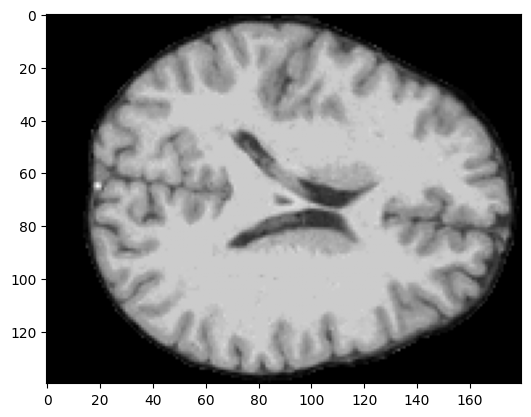

In [137]:
img1 = nib.load("OASIS Raw Data/brainmasks/OAS30005_brainmask.mgz")
brain1 = img1.get_fdata()

height_cut_lower = 70
height_cut_upper = 70
width_cut_lower = 100
width_cut_upper = 80
# height_cut_lower = 70
# height_cut_upper = 20
# width_cut_lower = 50
# width_cut_upper = 50

centralized_brain = centralize_brain(brain1, height_cut_lower, height_cut_upper, width_cut_lower, width_cut_upper, 11)
centralized_brain = centralized_brain / np.max(centralized_brain)

plt.imshow(centralized_brain, cmap = "gray")
plt.show()

In [55]:
patient_full_data = pd.read_csv("OASIS Raw Data/patients_MRI_metadata.csv")

height_cut_lower = 70
height_cut_upper = 70
width_cut_lower = 100
width_cut_upper = 80
# height_cut_lower = 70
# height_cut_upper = 20
# width_cut_lower = 50
# width_cut_upper = 50

brain_imgs = np.zeros( (patient_full_data.shape[0], 140, 180), dtype = "float32" )
# brain_imgs = np.zeros( (patient_full_data.shape[0], 90, 100), dtype = "float32" )

for i in tqdm(range(patient_full_data.shape[0])):
    subject_id = patient_full_data.loc[i, "oasis_id"]
    img = nib.load("OASIS Raw Data/brainmasks/{}_brainmask.mgz".format(subject_id))
    brain = img.get_fdata()
    centralized_brain = centralize_brain(brain, height_cut_lower, height_cut_upper, width_cut_lower, width_cut_upper, 11)
    centralized_brain = centralized_brain / np.max(centralized_brain)
    brain_imgs[i,:,:] = centralized_brain

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 737/737 [02:55<00:00,  4.20it/s]


In [56]:
np.save("OASIS Data/patients_images", brain_imgs)

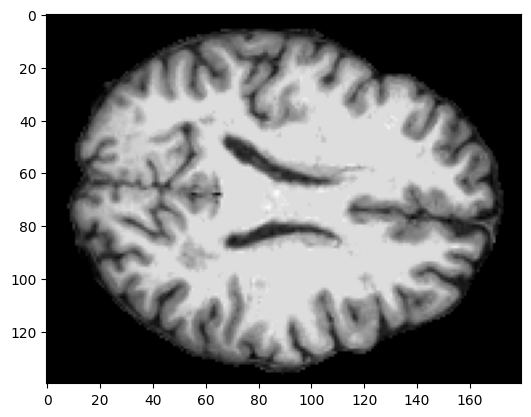

In [57]:
plt.imshow(brain_imgs[10], cmap = "gray")
plt.show()